# Self-Refine across model sizes

This notebook analyzes the Self-Refine effect across three tiers:

| tier | size band | families |
|------|-----------|----------|
| `very_small` | 4–9B  | Gemma 3 4B, Ministral 3 8B, Qwen3.5 9B |
| `small`      | 12–14B | Gemma 3 12B, Ministral 3 14B, Qwen3 14B |
| `medium`     | 24–27B | Gemma 3 27B, Mistral Small 24B, Qwen3.5 27B |

The experiment is self-play: in every game both seats are the same model, and
each of these three strategy assignments is run 30 times per model. The
assignments are coded by two letters, the first for Player 1 and the second for
Player 2, with `D` = default and `R` = self-refine:

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |


In [13]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png",):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


def print_plot_frame(name, df, columns=None, sort_by=None, round_cols=None):
    out = df.copy()
    if columns is not None:
        out = out.loc[:, columns]
    if sort_by is not None:
        out = out.sort_values(sort_by).reset_index(drop=True)
    if round_cols:
        for col, digits in round_cols.items():
            if col in out.columns:
                out[col] = out[col].round(digits)
    print(f"PLOT_DATA[{name}]")
    print(out.to_json(orient="records"))


# All three tiers, in increasing-size order, with their display labels.
SIZES = list(style.SIZE_ORDER)            # ["very_small", "small", "medium"]
SIZE_LABEL = style.SIZE_LABEL             # {"very_small": "4-9B", ...}
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2"}
# Strategy-condition palette (orange baseline, blue single-seat refine). The
# symmetric both-refine (RR) condition is excluded from this analysis.
COND_COLORS = {"DD": "#de8f05", "RD": "#0173b2", "DR": "#0173b2"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)"}
SETTING_COLORS = {"default": "#de8f05", "refine": "#0173b2"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#de8f05", "unchanged": "#0173b2",
                    "more_generous": "#029e73", "no_proposal": "#949494"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}
# Per-tier colors for the trend figures.
SIZE_COLORS = {"very_small": "#56b4e9", "small": "#0173b2", "medium": "#012a4a"}

# Lowercase game keys as they appear in the trace frames (TRACE/TSUM), plus a
# display map back to the title-case names used everywhere else.
games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}

In [14]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

_LOADERS = {"Trading": load_trading_sr, "Ultimatum": load_ultimatum_sr,
            "BuySell": load_buysell_sr}

# Nested outcome frames: OUT[size][game]. A tier/game with no logs yields an
# empty frame, which every plotting helper below guards against.
OUT, COMP = {}, {}
for sz in SIZES:
    OUT[sz] = {}
    for g, loader in _LOADERS.items():
        df = loader(sz)
        if len(df):
            df["game"] = g
            df["family"] = df["model"].map(family_of)
        OUT[sz][g] = df
    COMP[sz] = completion_rows(sz)

# Trace frames carry every size; keep them whole and filter per tier in-section.
TRACE_ALL = load_trace_rows()
TSUM_ALL = load_trace_summary()

# Sample sizes: completed decisive games underpin every win rate, so show them.
for sz in SIZES:
    rows = []
    for g in GAME_ORDER:
        df = OUT[sz][g]
        for c in COND_ORDER:
            sub = df[df["cond"] == c] if len(df) else df
            decisive = int((sub["win_1"] | sub["win_2"]).sum()) if len(sub) else 0
            rows.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
    tbl = (pd.DataFrame(rows)
           .pivot_table(index="game", columns="cond",
                        values=["completed", "decisive"])
           .reindex(GAME_ORDER))
    print(f"=== {sz} ({SIZE_LABEL[sz]}) : completed runs / decisive games ===")
    print(tbl.to_string())
    print()

2026-06-18 10:37:30.914 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 10:37:33.696 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


=== very_small (4–9B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        63.0  66.0  63.0     46.0  53.0  47.0
Ultimatum      74.0  70.0  74.0     37.0  34.0  45.0
BuySell        65.0  67.0  52.0     38.0  49.0  39.0

=== small (12–14B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        77.0  89.0  89.0     61.0  74.0  81.0
Ultimatum      80.0  89.0  83.0     59.0  67.0  59.0
BuySell        84.0  88.0  87.0     70.0  82.0  78.0

=== medium (24–27B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        58.0  69.0  6

## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable. The per-tier facets repeat the small-tier completion view for each
size; the trend figure then puts size on the x-axis so the format effect of
refinement can be read against model scale.

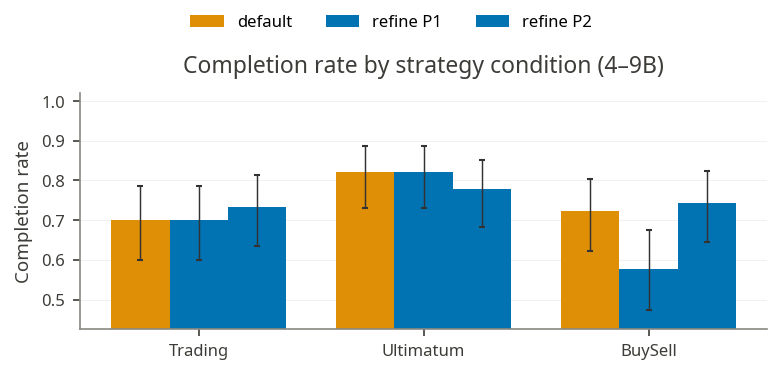

PLOT_DATA[completion_by_condition_very_small]
[{"game":"BuySell","cond":"DD","k":65,"n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","k":67,"n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","k":52,"n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"Trading","cond":"DD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Trading","cond":"DR","k":66,"n":90,"rate":0.733333,"lo":0.633802,"hi":0.813762},{"game":"Trading","cond":"RD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Ultimatum","cond":"DD","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503},{"game":"Ultimatum","cond":"DR","k":70,"n":90,"rate":0.777778,"lo":0.681527,"hi":0.851287},{"game":"Ultimatum","cond":"RD","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503}]


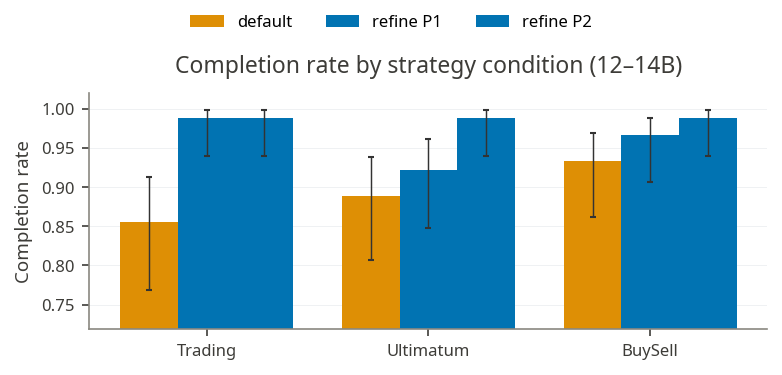

PLOT_DATA[completion_by_condition_small]
[{"game":"BuySell","cond":"DD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"RD","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"Trading","cond":"DD","k":77,"n":90,"rate":0.855556,"lo":0.768401,"hi":0.9136},{"game":"Trading","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Trading","cond":"RD","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"DD","k":80,"n":90,"rate":0.888889,"lo":0.807422,"hi":0.938517},{"game":"Ultimatum","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"RD","k":83,"n":90,"rate":0.922222,"lo":0.848061,"hi":0.961815}]


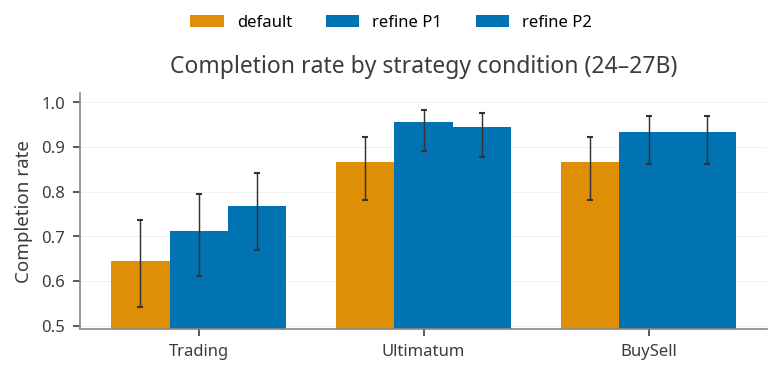

PLOT_DATA[completion_by_condition_medium]
[{"game":"BuySell","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DR","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"Trading","cond":"DD","k":58,"n":90,"rate":0.644444,"lo":0.541502,"hi":0.735561},{"game":"Trading","cond":"DR","k":69,"n":90,"rate":0.766667,"lo":0.669483,"hi":0.842018},{"game":"Trading","cond":"RD","k":64,"n":90,"rate":0.711111,"lo":0.61036,"hi":0.794579},{"game":"Ultimatum","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"Ultimatum","cond":"DR","k":85,"n":90,"rate":0.944444,"lo":0.876463,"hi":0.976039},{"game":"Ultimatum","cond":"RD","k":86,"n":90,"rate":0.955556,"lo":0.891231,"hi":0.982583}]


In [15]:
# Per-tier completion facet: completion rate by strategy condition, one figure
# per tier. Mirrors the small-tier notebook's `completion_by_condition`.
def plot_completion(sz):
    comp = COMP[sz]
    if comp is None or comp.empty:
        print(f"[skip] no completion data for {sz}")
        return None
    cc = (comp.groupby(["game", "cond"])
          .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
    cc = cc[cc["cond"].isin(COND_ORDER)].copy()  # drop RR (excluded from this analysis)
    cc["rate"] = cc["k"] / cc["n"]
    cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    games_present = [g for g in GAME_ORDER if g in set(cc["game"])]
    x = np.arange(len(games_present)); width = 0.26
    fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
    for i, c in enumerate(COND_ORDER):
        sub = cc[cc["cond"] == c].set_index("game").reindex(games_present)
        pos = x + (i - (len(COND_ORDER) - 1) / 2) * width
        ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ymin = max(0.0, float(cc[["rate", "lo"]].min().min()) - 0.05)
    ax.set_xticks(x, games_present); ax.set_ylabel("Completion rate")
    ax.set_ylim(ymin, 1.02)
    ax.set_title(f"Completion rate by strategy condition ({SIZE_LABEL[sz]})")
    fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
               ncols=3, frameon=False)
    save_plot(fig, f"completion_by_condition_{sz}"); plt.show()
    print_plot_frame(
        f"completion_by_condition_{sz}", cc,
        columns=["game", "cond", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "cond"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return cc


COMP_BY_TIER = {sz: plot_completion(sz) for sz in SIZES}

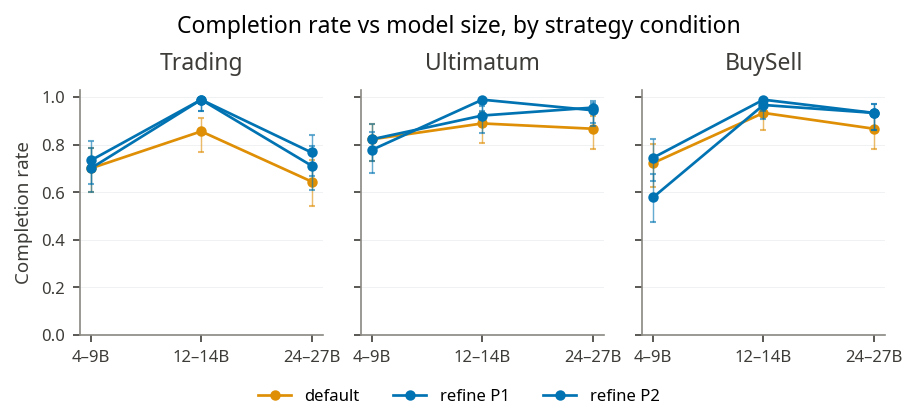

PLOT_DATA[completion_by_tier]
[{"game":"BuySell","cond":"DD","size":"medium","n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DD","size":"small","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DD","size":"very_small","n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","size":"small","n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"DR","size":"very_small","n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","size":"small","n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"BuySell","cond":"RD","size":"very_small","n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"Trading","cond":"DD","size":"medium","n":90,"rate":0.644444,"lo":0.541502,

In [16]:
# Tier trend: completion rate vs model size, one panel per game, one line per
# strategy condition. Reads whether Self-Refine's format lift survives across
# scale.
trend_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.7), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for c in COND_ORDER:
        ys, los, his = [], [], []
        for sz in SIZES:
            cc = COMP_BY_TIER.get(sz)
            if cc is None:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan); continue
            row = cc[(cc["game"] == g) & (cc["cond"] == c)]
            if len(row):
                r = row.iloc[0]
                ys.append(r["rate"]); los.append(r["lo"]); his.append(r["hi"])
                trend_rows.append(dict(game=g, cond=c, size=sz, rate=r["rate"],
                                       lo=r["lo"], hi=r["hi"], n=int(r["n"])))
            else:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan)
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=COND_COLORS[c],
                label=COND_LABEL[c])
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=COND_COLORS[c], lw=0.7, capsize=1.5, alpha=0.6)
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("Completion rate")
fig.suptitle("Completion rate vs model size, by strategy condition")
# de-duplicate the legend (RD and DR share a color/label group)
h, l = axes[0].get_legend_handles_labels()
seen = dict(zip(l, h))
fig.legend(seen.values(), seen.keys(), loc="outside lower center", ncols=3, frameon=False)
save_plot(fig, "completion_by_tier"); plt.show()

print_plot_frame(
    "completion_by_tier", pd.DataFrame(trend_rows),
    columns=["game", "cond", "size", "k" if False else "n", "rate", "lo", "hi"],
    sort_by=["game", "cond", "size"],
    round_cols={"rate": 6, "lo": 6, "hi": 6})

## 2. Refining impact on winrate and payoff

Each seat is compared against its own seat-matched `DD` baseline:

- **refine P1** is Player 1 in `RD` versus Player 1 in `DD`,
- **refine P2** is Player 2 in `DR` versus Player 2 in `DD`.

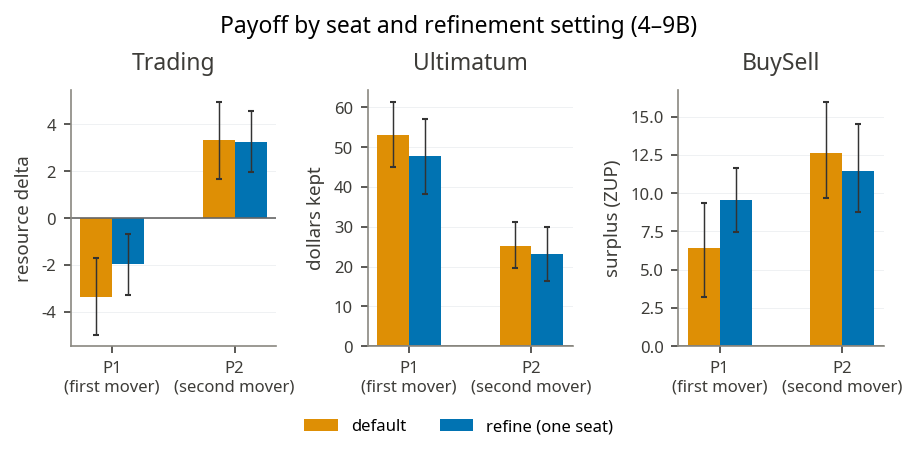

PLOT_DATA[refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"default","n":65,"mean":6.446154,"lo":3.215385,"hi":9.323077},{"game":"BuySell","seat":1,"setting":"refine","n":52,"mean":9.538462,"lo":7.480769,"hi":11.634615},{"game":"BuySell","seat":2,"setting":"default","n":65,"mean":12.630769,"lo":9.676923,"hi":15.938462},{"game":"BuySell","seat":2,"setting":"refine","n":67,"mean":11.462687,"lo":8.776119,"hi":14.477985},{"game":"Trading","seat":1,"setting":"default","n":63,"mean":-3.349206,"lo":-4.968651,"hi":-1.68254},{"game":"Trading","seat":1,"setting":"refine","n":63,"mean":-1.936508,"lo":-3.285714,"hi":-0.666667},{"game":"Trading","seat":2,"setting":"default","n":63,"mean":3.349206,"lo":1.68254,"hi":4.968651},{"game":"Trading","seat":2,"setting":"refine","n":66,"mean":3.257576,"lo":1.969318,"hi":4.576136},{"game":"Ultimatum","seat":1,"setting":"default","n":74,"mean":53.148649,"lo":45.10777,"hi":61.297297},{"game":"Ultimatum","seat":1,"setting":"refine","n":74,

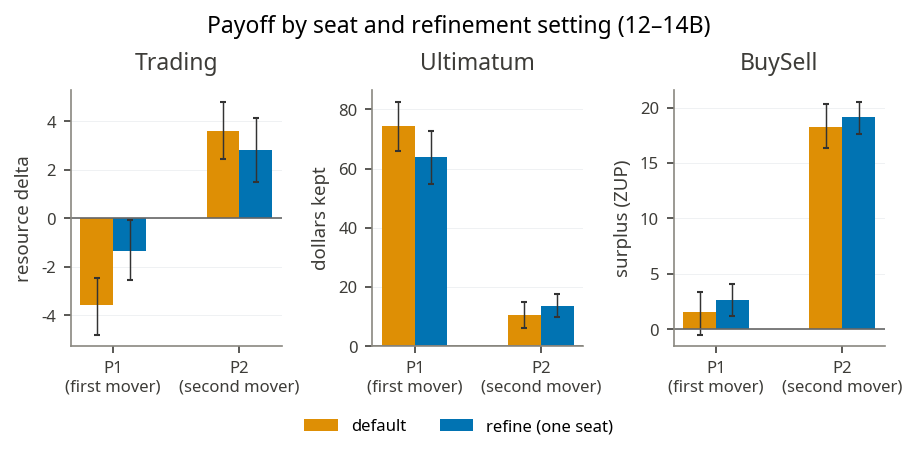

PLOT_DATA[refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"default","n":84,"mean":1.547619,"lo":-0.464286,"hi":3.416667},{"game":"BuySell","seat":1,"setting":"refine","n":87,"mean":2.678161,"lo":1.229885,"hi":4.103448},{"game":"BuySell","seat":2,"setting":"default","n":84,"mean":18.214286,"lo":16.309226,"hi":20.285714},{"game":"BuySell","seat":2,"setting":"refine","n":88,"mean":19.102273,"lo":17.625,"hi":20.534375},{"game":"Trading","seat":1,"setting":"default","n":77,"mean":-3.571429,"lo":-4.805195,"hi":-2.454545},{"game":"Trading","seat":1,"setting":"refine","n":89,"mean":-1.337079,"lo":-2.573034,"hi":-0.089888},{"game":"Trading","seat":2,"setting":"default","n":77,"mean":3.571429,"lo":2.454545,"hi":4.805195},{"game":"Trading","seat":2,"setting":"refine","n":89,"mean":2.820225,"lo":1.483146,"hi":4.146348},{"game":"Ultimatum","seat":1,"setting":"default","n":80,"mean":74.5,"lo":66.074688,"hi":82.45},{"game":"Ultimatum","seat":1,"setting":"refine","n":83,"mean":63.90

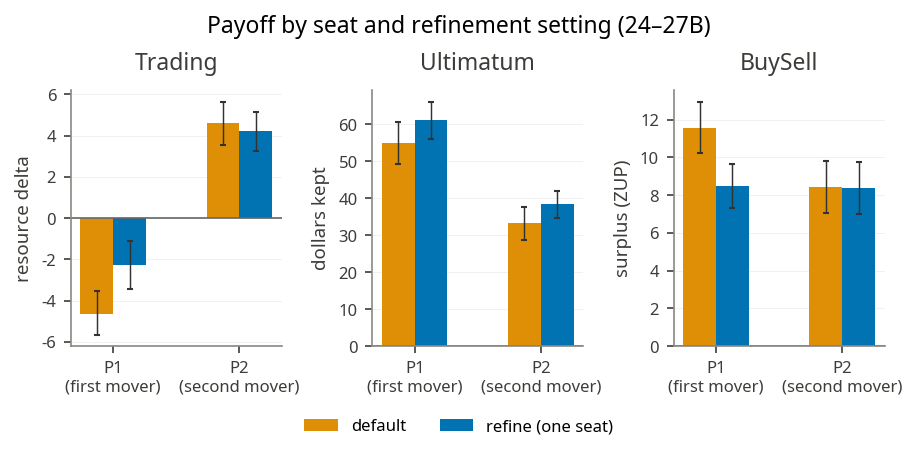

PLOT_DATA[refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"default","n":78,"mean":11.564103,"lo":10.205128,"hi":12.923077},{"game":"BuySell","seat":1,"setting":"refine","n":84,"mean":8.5,"lo":7.297619,"hi":9.666667},{"game":"BuySell","seat":2,"setting":"default","n":78,"mean":8.435897,"lo":7.076923,"hi":9.794872},{"game":"BuySell","seat":2,"setting":"refine","n":84,"mean":8.369048,"lo":6.999702,"hi":9.75},{"game":"Trading","seat":1,"setting":"default","n":58,"mean":-4.637931,"lo":-5.655172,"hi":-3.534483},{"game":"Trading","seat":1,"setting":"refine","n":64,"mean":-2.265625,"lo":-3.421875,"hi":-1.09375},{"game":"Trading","seat":2,"setting":"default","n":58,"mean":4.637931,"lo":3.534483,"hi":5.655172},{"game":"Trading","seat":2,"setting":"refine","n":69,"mean":4.202899,"lo":3.275362,"hi":5.130435},{"game":"Ultimatum","seat":1,"setting":"default","n":78,"mean":55.051282,"lo":49.141026,"hi":60.551603},{"game":"Ultimatum","seat":1,"setting":"refine","n":86,"mean":61.267

In [17]:
# Seat-resolved comparisons reused by both the facet figures and the trend
# figures below. Every comparison is against the seat-matched DD baseline.
SEAT_SETTING = ["default", "refine"]
_SEAT_COND = {(1, "default"): "DD", (1, "refine"): "RD",
              (2, "default"): "DD", (2, "refine"): "DR"}


def seat_payoff(df, seat, setting):
    if not len(df):
        return np.array([], float)
    col = "payoff_1" if seat == 1 else "payoff_2"
    return df[df["cond"] == _SEAT_COND[(seat, setting)]][col].values.astype(float)


def seat_winrate(df, seat, setting):
    if not len(df):
        return np.nan, 0, 0
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    return win_rate(w, l)


def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    if not len(ref) or not len(base):
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


# Per-tier facet: one panel per game, two seat groups (P1, P2), each with
# default / refine-this-seat bars carrying bootstrap CIs.
def plot_seat_payoff(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no payoff data for {sz}")
        return None
    seat_plot = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            centers, los, his = [], [], []
            for seat in (1, 2):
                vals = seat_payoff(df, seat, s)
                center = np.mean(vals) if len(vals) else np.nan
                lo, hi = bootstrap_ci(vals)
                centers.append(center); los.append(lo); his.append(hi)
                seat_plot.append(dict(size=sz, game=g, seat=seat, setting=s,
                                      n=len(vals), mean=center, lo=lo, hi=hi))
            pos = group_x + (i - (len(SEAT_SETTING) - 1) / 2) * width
            ax.bar(pos, centers, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, centers,
                        yerr=errbars_from_ci(np.array(centers, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0, lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
    fig.suptitle(f"Payoff by seat and refinement setting ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, frameon=False)
    save_plot(fig, f"refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"refine_effect_by_seat_{sz}", pd.DataFrame(seat_plot),
        columns=["game", "seat", "setting", "n", "mean", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"mean": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_plot)


for sz in SIZES:
    plot_seat_payoff(sz)

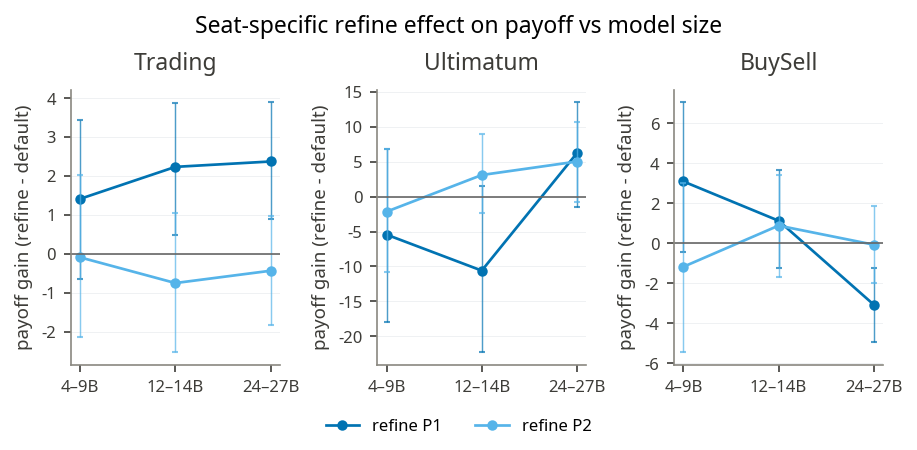

PLOT_DATA[refine_payoff_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","n":84,"delta":-3.064103,"lo":-4.929853,"hi":-1.243475},{"game":"BuySell","seat":"P1","size":"small","n":87,"delta":1.130542,"lo":-1.247137,"hi":3.663773},{"game":"BuySell","seat":"P1","size":"very_small","n":52,"delta":3.092308,"lo":-0.454519,"hi":7.042404},{"game":"BuySell","seat":"P2","size":"medium","n":84,"delta":-0.06685,"lo":-1.964354,"hi":1.890293},{"game":"BuySell","seat":"P2","size":"small","n":88,"delta":0.887987,"lo":-1.689976,"hi":3.394048},{"game":"BuySell","seat":"P2","size":"very_small","n":67,"delta":-1.168083,"lo":-5.435752,"hi":2.998375},{"game":"Trading","seat":"P1","size":"medium","n":64,"delta":2.372306,"lo":0.883621,"hi":3.890746},{"game":"Trading","seat":"P1","size":"small","n":89,"delta":2.23435,"lo":0.471735,"hi":3.881796},{"game":"Trading","seat":"P1","size":"very_small","n":63,"delta":1.412698,"lo":-0.650794,"hi":3.428571},{"game":"Trading","seat":"P2","size":"medium","n":

In [18]:
# Tier trend: seat-specific refine effect (refine that seat - its own DD
# baseline, native payoff units) vs model size, one panel per game, one line per
# seat, with a bootstrap CI on the difference.
SEAT_EFFECT_COLORS = {1: "#0173b2", 2: "#56b4e9"}
eff_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys, los, his = [], [], []
        for k, sz in enumerate(SIZES):
            df = OUT[sz][g]
            base = seat_payoff(df, seat, "default")
            ref = seat_payoff(df, seat, "refine")
            if len(base) and len(ref):
                d = ref.mean() - base.mean()
                lo, hi = _diff_ci(ref, base, seed=7 + seat + 3 * k)
            else:
                d, lo, hi = np.nan, np.nan, np.nan
            ys.append(d); los.append(lo); his.append(hi)
            eff_rows.append(dict(game=g, seat=f"P{seat}", size=sz, delta=d,
                                 lo=lo, hi=hi, n=len(ref)))
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=SEAT_EFFECT_COLORS[seat],
                label=f"refine P{seat}")
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=SEAT_EFFECT_COLORS[seat], lw=0.7,
                    capsize=1.5, alpha=0.7)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylabel("payoff gain (refine - default)")
fig.suptitle("Seat-specific refine effect on payoff vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_payoff_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_payoff_effect_by_tier", pd.DataFrame(eff_rows),
    columns=["game", "seat", "size", "n", "delta", "lo", "hi"],
    sort_by=["game", "seat", "size"],
    round_cols={"delta": 6, "lo": 6, "hi": 6})

### Win rate by seat

The same seat-resolved comparison read as win rate (ties excluded). The 0.5 line
is parity: a seat neither helped nor hurt relative to a default opponent. The
trend figure tracks the win-rate shift from refining a seat (refine-this-seat
minus the seat-matched `DD` win rate) across model size.

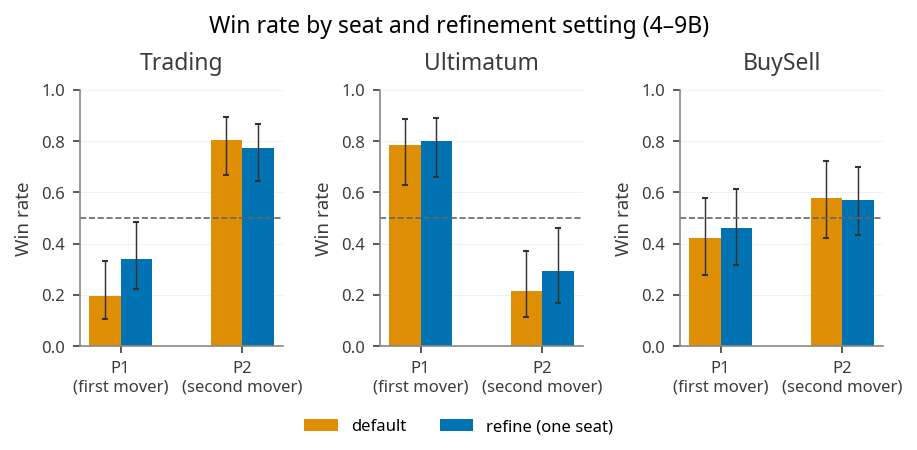

PLOT_DATA[winrate_refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"default","k":16,"n":38,"rate":0.421053,"lo":0.278525,"hi":0.578077},{"game":"BuySell","seat":1,"setting":"refine","k":18,"n":39,"rate":0.461538,"lo":0.315669,"hi":0.614306},{"game":"BuySell","seat":2,"setting":"default","k":22,"n":38,"rate":0.578947,"lo":0.421923,"hi":0.721475},{"game":"BuySell","seat":2,"setting":"refine","k":28,"n":49,"rate":0.571429,"lo":0.432705,"hi":0.699767},{"game":"Trading","seat":1,"setting":"default","k":9,"n":46,"rate":0.195652,"lo":0.106506,"hi":0.331713},{"game":"Trading","seat":1,"setting":"refine","k":16,"n":47,"rate":0.340426,"lo":0.221674,"hi":0.483291},{"game":"Trading","seat":2,"setting":"default","k":37,"n":46,"rate":0.804348,"lo":0.668287,"hi":0.893494},{"game":"Trading","seat":2,"setting":"refine","k":41,"n":53,"rate":0.773585,"lo":0.644737,"hi":0.865454},{"game":"Ultimatum","seat":1,"setting":"default","k":29,"n":37,"rate":0.783784,"lo":0.628049,"hi":0.8861

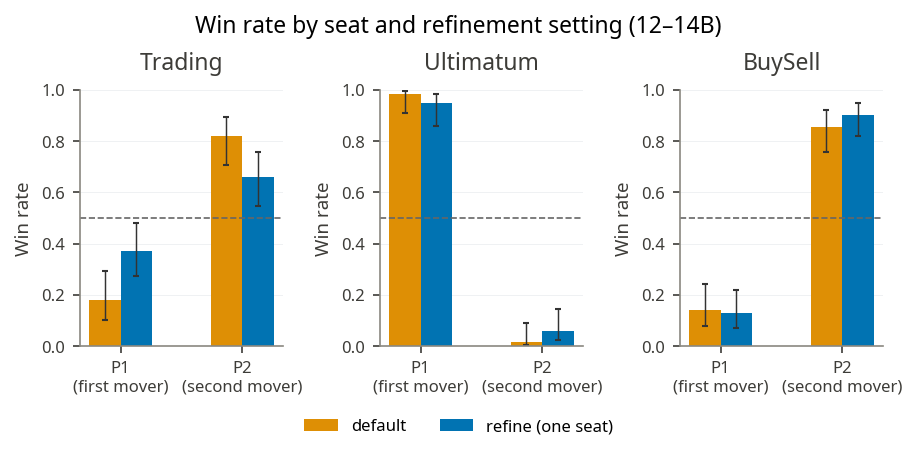

PLOT_DATA[winrate_refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"default","k":10,"n":70,"rate":0.142857,"lo":0.079489,"hi":0.243384},{"game":"BuySell","seat":1,"setting":"refine","k":10,"n":78,"rate":0.128205,"lo":0.071153,"hi":0.22016},{"game":"BuySell","seat":2,"setting":"default","k":60,"n":70,"rate":0.857143,"lo":0.756616,"hi":0.920511},{"game":"BuySell","seat":2,"setting":"refine","k":74,"n":82,"rate":0.902439,"lo":0.819128,"hi":0.949731},{"game":"Trading","seat":1,"setting":"default","k":11,"n":61,"rate":0.180328,"lo":0.103791,"hi":0.294742},{"game":"Trading","seat":1,"setting":"refine","k":30,"n":81,"rate":0.37037,"lo":0.273317,"hi":0.479163},{"game":"Trading","seat":2,"setting":"default","k":50,"n":61,"rate":0.819672,"lo":0.705258,"hi":0.896209},{"game":"Trading","seat":2,"setting":"refine","k":49,"n":74,"rate":0.662162,"lo":0.548785,"hi":0.759534},{"game":"Ultimatum","seat":1,"setting":"default","k":58,"n":59,"rate":0.983051,"lo":0.910043,"hi":0.997002},{"

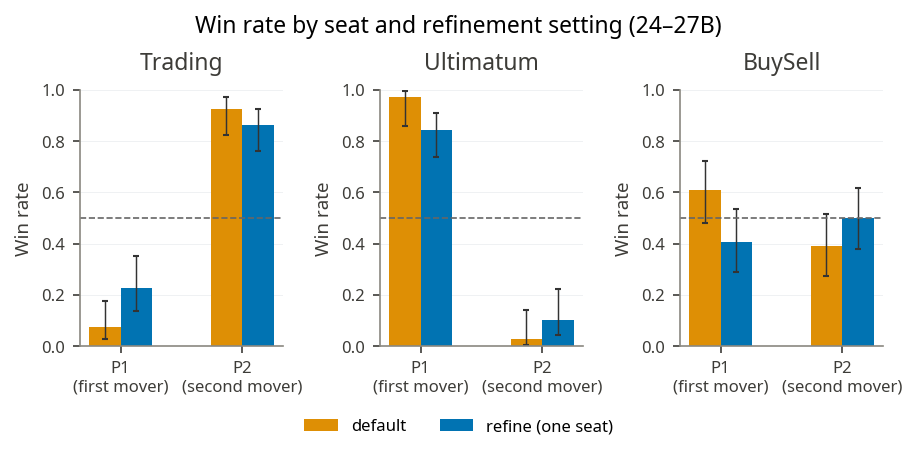

PLOT_DATA[winrate_refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"default","k":36,"n":59,"rate":0.610169,"lo":0.482663,"hi":0.724206},{"game":"BuySell","seat":1,"setting":"refine","k":24,"n":59,"rate":0.40678,"lo":0.29089,"hi":0.534066},{"game":"BuySell","seat":2,"setting":"default","k":23,"n":59,"rate":0.389831,"lo":0.275794,"hi":0.517337},{"game":"BuySell","seat":2,"setting":"refine","k":32,"n":64,"rate":0.5,"lo":0.381021,"hi":0.618979},{"game":"Trading","seat":1,"setting":"default","k":4,"n":54,"rate":0.074074,"lo":0.029182,"hi":0.175541},{"game":"Trading","seat":1,"setting":"refine","k":13,"n":57,"rate":0.22807,"lo":0.138419,"hi":0.35206},{"game":"Trading","seat":2,"setting":"default","k":50,"n":54,"rate":0.925926,"lo":0.824459,"hi":0.970818},{"game":"Trading","seat":2,"setting":"refine","k":57,"n":66,"rate":0.863636,"lo":0.760704,"hi":0.926567},{"game":"Ultimatum","seat":1,"setting":"default","k":35,"n":36,"rate":0.972222,"lo":0.858303,"hi":0.99508},{"game":"U

In [19]:
# Per-tier facet: seat-resolved win rate (ties excluded) under default / refine
# this seat, one panel per game.
def plot_seat_winrate(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no win-rate data for {sz}")
        return None
    seat_wr = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            rates, los, his = [], [], []
            for seat in (1, 2):
                rate, k, n = seat_winrate(df, seat, s)
                lo, hi = wilson_ci(k, n)
                rates.append(rate); los.append(lo); his.append(hi)
                seat_wr.append(dict(size=sz, game=g, seat=seat, setting=s,
                                    rate=rate, k=k, n=n, lo=lo, hi=hi))
            pos = group_x + (i - (len(SEAT_SETTING) - 1) / 2) * width
            ax.bar(pos, rates, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, rates,
                        yerr=errbars_from_ci(np.array(rates, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel("Win rate"); ax.set_ylim(0, 1.0)
    fig.suptitle(f"Win rate by seat and refinement setting ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, frameon=False)
    save_plot(fig, f"winrate_refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"winrate_refine_effect_by_seat_{sz}", pd.DataFrame(seat_wr),
        columns=["game", "seat", "setting", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_wr)


for sz in SIZES:
    plot_seat_winrate(sz)

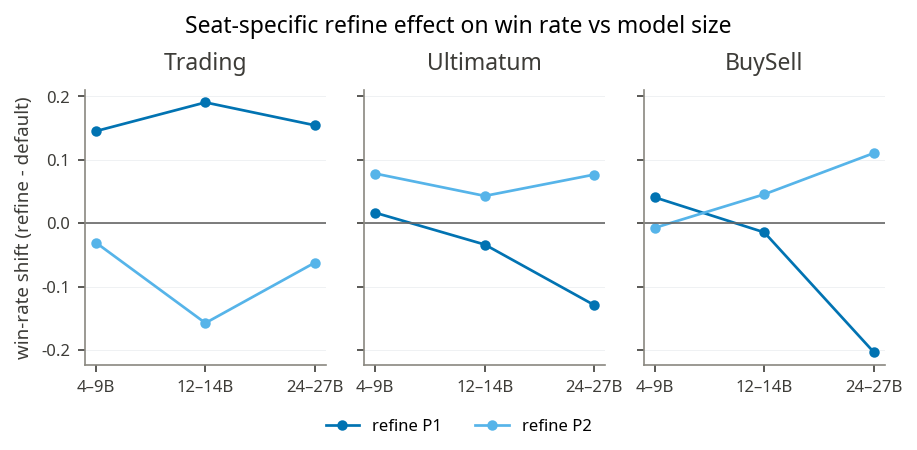

PLOT_DATA[refine_winrate_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","default_wr":0.610169,"refine_wr":0.40678,"delta":-0.20339},{"game":"BuySell","seat":"P1","size":"small","default_wr":0.142857,"refine_wr":0.128205,"delta":-0.014652},{"game":"BuySell","seat":"P1","size":"very_small","default_wr":0.421053,"refine_wr":0.461538,"delta":0.040486},{"game":"BuySell","seat":"P2","size":"medium","default_wr":0.389831,"refine_wr":0.5,"delta":0.110169},{"game":"BuySell","seat":"P2","size":"small","default_wr":0.857143,"refine_wr":0.902439,"delta":0.045296},{"game":"BuySell","seat":"P2","size":"very_small","default_wr":0.578947,"refine_wr":0.571429,"delta":-0.007519},{"game":"Trading","seat":"P1","size":"medium","default_wr":0.074074,"refine_wr":0.22807,"delta":0.153996},{"game":"Trading","seat":"P1","size":"small","default_wr":0.180328,"refine_wr":0.37037,"delta":0.190043},{"game":"Trading","seat":"P1","size":"very_small","default_wr":0.195652,"refine_wr":0.340426,"delta":0.

In [20]:
# Tier trend: win-rate shift from refining a seat (refine-this-seat win rate
# minus the seat-matched DD win rate) vs model size, one panel per game, one
# line per seat.
wr_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys = []
        for sz in SIZES:
            df = OUT[sz][g]
            base, _, bn = seat_winrate(df, seat, "default")
            ref, _, rn = seat_winrate(df, seat, "refine")
            d = (ref - base) if (bn and rn) else np.nan
            ys.append(d)
            wr_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                                default_wr=base, refine_wr=ref, delta=d))
        ax.plot(xs, np.array(ys, float), marker="o", ms=4, lw=1.3,
                color=SEAT_EFFECT_COLORS[seat], label=f"refine P{seat}")
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g)
axes[0].set_ylabel("win-rate shift (refine - default)")
fig.suptitle("Seat-specific refine effect on win rate vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_winrate_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_winrate_effect_by_tier", pd.DataFrame(wr_rows),
    columns=["game", "seat", "size", "default_wr", "refine_wr", "delta"],
    sort_by=["game", "seat", "size"],
    round_cols={"default_wr": 6, "refine_wr": 6, "delta": 6})

### Matched default-vs-refine scatter

Hold `game x seat x family` fixed, put the seat's `DD` outcome on the x-axis and
the matched refined outcome on the y-axis. Points above the diagonal are gains
from refinement; points below are losses. One facet per tier. The payoff panel
uses each game's payoff span so the three games sit on the same 0-1 scale.

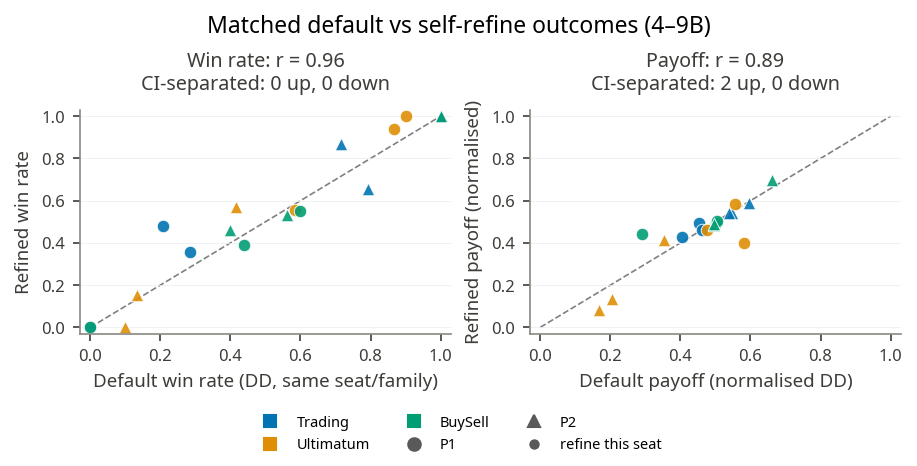

PLOT_DATA[default_vs_refine_scatter_very_small]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":-11.083333,"refined_pay":4.0,"pay_delta":15.083333,"pay_lo":4.0,"pay_hi":26.752083,"pay_rel":"refine>default","default_pay_norm":0.289167,"refined_pay_norm":0.44,"pay_norm_delta":0.150833},{"game":"BuySell","family":"ministral","seat":1,"setting":"refine","default_wr":0.6,"refined_wr":0.55,"wr_delta":-0.05,"wr_rel":"overlap","default_pay":10.28,"refined_pay":9.434783,"pay_delta":-0.845217,"pay_lo":-5.384565,"pay_hi":3.732217,"pay_rel":"overlap","default_pay_norm":0.5028,"refined_pay_norm":0.494348,"pay_norm_delta":-0.008452},{"game":"BuySell","family":"qwen","seat":1,"setting":"refine","default_wr":0.4375,"refined_wr":0.388889,"wr_delta":-0.048611,"wr_rel":"overlap","default_pay":10.535714,"refined_pay":10.269231,"pay_delta":-0.266484,"pay_lo":-3.255632,"pay_hi":2.739148,"pay_rel":"overlap","def

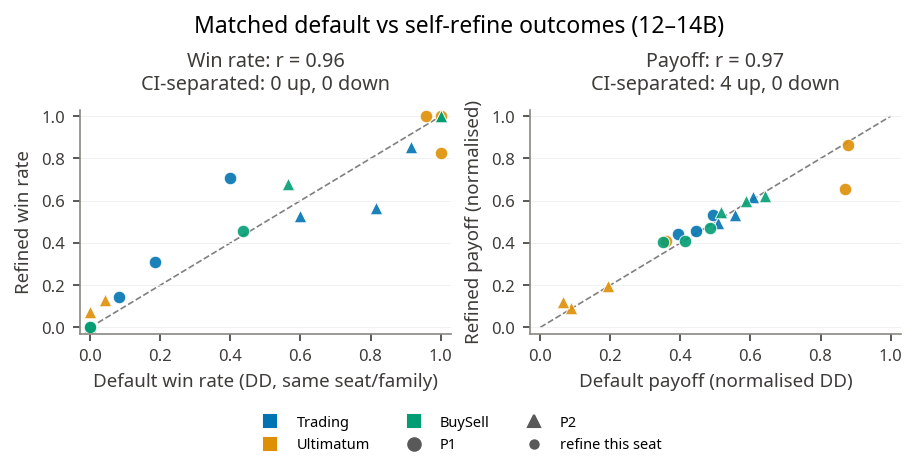

PLOT_DATA[default_vs_refine_scatter_small]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":-4.866667,"refined_pay":0.206897,"pay_delta":5.073563,"pay_lo":1.42954,"pay_hi":9.016236,"pay_rel":"refine>default","default_pay_norm":0.351333,"refined_pay_norm":0.402069,"pay_norm_delta":0.050736},{"game":"BuySell","family":"ministral","seat":1,"setting":"refine","default_wr":0.434783,"refined_wr":0.454545,"wr_delta":0.019763,"wr_rel":"overlap","default_pay":8.310345,"refined_pay":7.0,"pay_delta":-1.310345,"pay_lo":-5.677555,"pay_hi":2.901509,"pay_rel":"overlap","default_pay_norm":0.483103,"refined_pay_norm":0.47,"pay_norm_delta":-0.013103},{"game":"BuySell","family":"qwen","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":1.4,"refined_pay":1.033333,"pay_delta":-0.366667,"pay_lo":-2.166667,"pay_hi":1.4,"pay_rel":"overlap","default_pay_norm

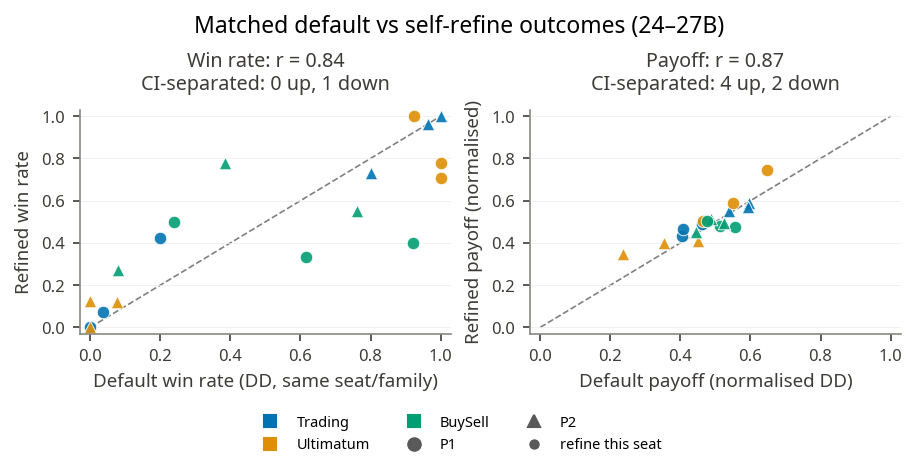

PLOT_DATA[default_vs_refine_scatter_medium]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.92,"refined_wr":0.4,"wr_delta":-0.52,"wr_rel":"refine<default","default_pay":15.466667,"refined_pay":7.433333,"pay_delta":-8.033333,"pay_lo":-10.8,"pay_hi":-5.266667,"pay_rel":"refine<default","default_pay_norm":0.554667,"refined_pay_norm":0.474333,"pay_norm_delta":-0.080333},{"game":"BuySell","family":"ministral","seat":1,"setting":"refine","default_wr":0.615385,"refined_wr":0.333333,"wr_delta":-0.282051,"wr_rel":"overlap","default_pay":11.368421,"refined_pay":7.8,"pay_delta":-3.568421,"pay_lo":-7.330526,"pay_hi":0.326526,"pay_rel":"overlap","default_pay_norm":0.513684,"refined_pay_norm":0.478,"pay_norm_delta":-0.035684},{"game":"BuySell","family":"qwen","seat":1,"setting":"refine","default_wr":0.238095,"refined_wr":0.5,"wr_delta":0.261905,"wr_rel":"overlap","default_pay":7.655172,"refined_pay":10.206897,"pay_delta":2.551724,"pay_lo":0.62069,"pay_hi":4.517241,"pay

In [21]:
from matplotlib.lines import Line2D

PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
GAME_COLORS = {"Trading": "#0173b2", "Ultimatum": "#de8f05", "BuySell": "#029e73"}
FAMILY_ORDER = ["gemma", "ministral", "qwen"]
FAMILY_LABEL = {"gemma": "Gemma", "ministral": "Ministral", "qwen": "Qwen"}
SEAT_MARKER = {1: "o", 2: "^"}
COMPARE_SETTINGS = ["refine"]
COMPARE_LABEL = {"refine": "refine this seat"}


def norm_payoff(game, payoff):
    lo, hi = PAYOFF_BOUNDS[game]
    return (payoff - lo) / (hi - lo)


def _seat_fam_payoff_values(df, seat, setting, fam):
    col = "payoff_1" if seat == 1 else "payoff_2"
    sub = df[(df["cond"] == _SEAT_COND[(seat, setting)]) & (df["family"] == fam)]
    return sub[col].values.astype(float)


def _seat_fam_winrate(df, seat, setting, fam):
    sub = df[(df["cond"] == _SEAT_COND[(seat, setting)]) & (df["family"] == fam)]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    rate, k, n = win_rate(w, l)
    lo, hi = wilson_ci(k, n)
    return rate, k, n, lo, hi


def _relation_from_ci(diff_lo, diff_hi, better="refine"):
    if diff_lo > 0:
        return f"{better}>default"
    if diff_hi < 0:
        return f"{better}<default"
    return "overlap"


def plot_matched_scatter(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no scatter data for {sz}")
        return None
    sr_rows = []
    for g in games_present:
        df = out[g]
        span = PAYOFF_BOUNDS[g][1] - PAYOFF_BOUNDS[g][0]
        for fam in FAMILY_ORDER:
            for seat in (1, 2):
                base_pay = _seat_fam_payoff_values(df, seat, "default", fam)
                base_wr, base_k, base_n, base_wr_lo, base_wr_hi = _seat_fam_winrate(df, seat, "default", fam)
                if len(base_pay) == 0:
                    continue
                base_pay_mean = float(np.mean(base_pay))
                for setting in COMPARE_SETTINGS:
                    ref_pay = _seat_fam_payoff_values(df, seat, setting, fam)
                    ref_wr, ref_k, ref_n, ref_wr_lo, ref_wr_hi = _seat_fam_winrate(df, seat, setting, fam)
                    if len(ref_pay) == 0:
                        continue
                    ref_pay_mean = float(np.mean(ref_pay))
                    pay_lo, pay_hi = _diff_ci(ref_pay, base_pay, seed=11 + seat + len(sr_rows))
                    wr_rel = "refine>default" if ref_wr_lo > base_wr_hi else (
                        "refine<default" if base_wr_lo > ref_wr_hi else "overlap")
                    sr_rows.append(dict(
                        size=sz, game=g, family=fam, seat=seat, setting=setting,
                        default_wr=base_wr, refined_wr=ref_wr, wr_delta=ref_wr - base_wr,
                        wr_rel=wr_rel, default_k=base_k, default_n=base_n,
                        refined_k=ref_k, refined_n=ref_n,
                        default_pay=base_pay_mean, refined_pay=ref_pay_mean,
                        pay_delta=ref_pay_mean - base_pay_mean,
                        pay_lo=pay_lo, pay_hi=pay_hi,
                        pay_rel=_relation_from_ci(pay_lo, pay_hi),
                        default_pay_norm=norm_payoff(g, base_pay_mean),
                        refined_pay_norm=norm_payoff(g, ref_pay_mean),
                        pay_norm_delta=(ref_pay_mean - base_pay_mean) / span))
    SR_CMP = pd.DataFrame(sr_rows)
    if SR_CMP.empty:
        print(f"[skip] no matched cells for {sz}")
        return None

    fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.0))
    for ax in (ax_wr, ax_pay):
        ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
        ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
    for _, r in SR_CMP.iterrows():
        marker = SEAT_MARKER[int(r.seat)]; color = GAME_COLORS[r.game]
        if r.setting == "refine":
            face, edge, lw, alpha = color, "white", 0.45, 0.9
        else:
            face, edge, lw, alpha = "none", color, 1.05, 0.95
        ax_wr.scatter(r.default_wr, r.refined_wr, s=36, marker=marker,
                      facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)
        ax_pay.scatter(r.default_pay_norm, r.refined_pay_norm, s=36, marker=marker,
                       facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)
    wr_r = SR_CMP[["default_wr", "refined_wr"]].corr().iloc[0, 1]
    pay_r = SR_CMP[["default_pay_norm", "refined_pay_norm"]].corr().iloc[0, 1]
    wr_up = int((SR_CMP.wr_rel == "refine>default").sum())
    wr_down = int((SR_CMP.wr_rel == "refine<default").sum())
    pay_up = int((SR_CMP.pay_rel == "refine>default").sum())
    pay_down = int((SR_CMP.pay_rel == "refine<default").sum())
    ax_wr.set_xlabel("Default win rate (DD, same seat/family)")
    ax_wr.set_ylabel("Refined win rate")
    ax_wr.set_title(f"Win rate: r = {wr_r:.2f}\nCI-separated: {wr_up} up, {wr_down} down", fontsize=9.5)
    ax_pay.set_xlabel("Default payoff (normalised DD)")
    ax_pay.set_ylabel("Refined payoff (normalised)")
    ax_pay.set_title(f"Payoff: r = {pay_r:.2f}\nCI-separated: {pay_up} up, {pay_down} down", fontsize=9.5)
    leg_game = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=g) for g in games_present]
    leg_seat = [Line2D([], [], marker=SEAT_MARKER[s], ls="", color="0.35", label=f"P{s}") for s in (1, 2)]
    leg_setting = [
        Line2D([], [], marker="o", ls="", markerfacecolor="0.35", markeredgecolor="white",
               color="0.35", label="refine this seat")]
    fig.legend(handles=leg_game + leg_seat + leg_setting, loc="outside lower center",
               ncols=3, frameon=False, fontsize=7)
    fig.suptitle(f"Matched default vs self-refine outcomes ({SIZE_LABEL[sz]})")
    save_plot(fig, f"default_vs_refine_scatter_{sz}"); plt.show()
    print_plot_frame(
        f"default_vs_refine_scatter_{sz}", SR_CMP,
        columns=["game", "family", "seat", "setting", "default_wr", "refined_wr",
                 "wr_delta", "wr_rel", "default_pay", "refined_pay", "pay_delta",
                 "pay_lo", "pay_hi", "pay_rel", "default_pay_norm",
                 "refined_pay_norm", "pay_norm_delta"],
        sort_by=["game", "seat", "family", "setting"],
        round_cols={"default_wr": 6, "refined_wr": 6, "wr_delta": 6,
                    "default_pay": 6, "refined_pay": 6, "pay_delta": 6,
                    "pay_lo": 6, "pay_hi": 6, "default_pay_norm": 6,
                    "refined_pay_norm": 6, "pay_norm_delta": 6})
    return SR_CMP


for sz in SIZES:
    plot_matched_scatter(sz)

## 3. How does refinement change the move?


## Annex — heatmaps

For the appendix: a single scannable view of *where* refining one seat moves the
outcome. Rows are game x seat, columns are model tier. Each cell is the seat's
**refine-this-seat** value minus its **seat-matched default (DD)** baseline, so
positive (blue) = refinement helped that seat, negative (red) = it hurt.
**Bold** cells mark the seat that is *disadvantaged* on default at that tier
(win rate < 0.5); a trailing `*` marks a bootstrap 95% CI on the difference that
excludes zero. The win-rate panel is in probability units; the payoff panel is
annotated in native game units but colored on each game's payoff range so the
three games are visually comparable.

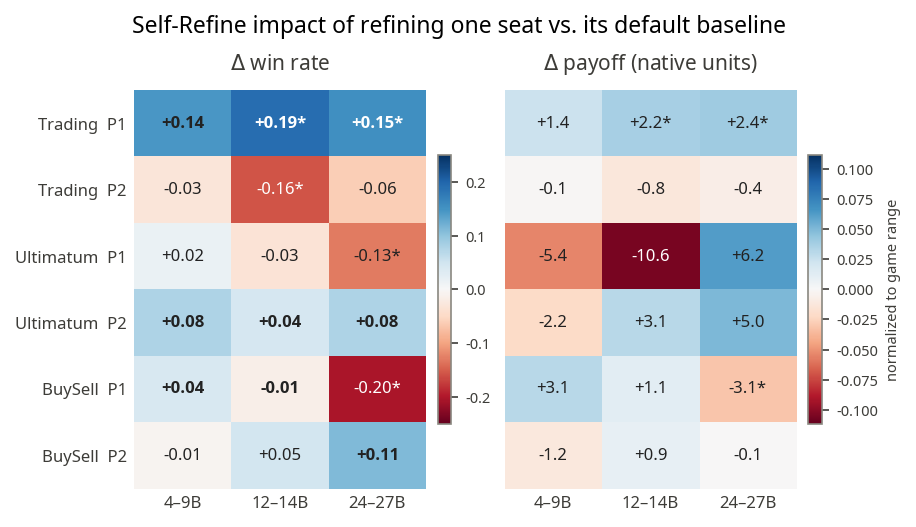

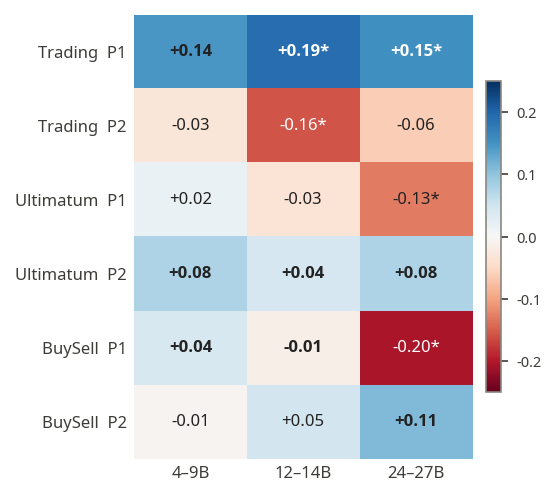

PLOT_DATA[refine_impact_heatmap]
[{"game":"Trading","seat":"P1","size":"very_small","wr_delta":0.1448,"wr_ci_excl0":false,"disadvantaged":true,"pay_delta":1.4127,"pay_ci_excl0":false},{"game":"Trading","seat":"P1","size":"small","wr_delta":0.19,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.2343,"pay_ci_excl0":true},{"game":"Trading","seat":"P1","size":"medium","wr_delta":0.154,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.3723,"pay_ci_excl0":true},{"game":"Trading","seat":"P2","size":"very_small","wr_delta":-0.0308,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.0916,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"small","wr_delta":-0.1575,"wr_ci_excl0":true,"disadvantaged":false,"pay_delta":-0.7512,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"medium","wr_delta":-0.0623,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.435,"pay_ci_excl0":false},{"game":"Ultimatum","seat":"P1","size":"very_small","wr_delta":0.0162,"wr_ci_excl0":

In [22]:
# Annex impact heatmaps: refine-one-seat minus seat-matched DD baseline.
# Win-rate delta (probability units) and payoff delta (native units, colored on
# each game's payoff range). Bold = disadvantaged seat (default WR < 0.5) at that
# tier; trailing * = bootstrap 95% CI on the difference excludes zero.
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}

_rows = [(g, s) for g in GAME_ORDER for s in (1, 2)]
_row_labels = [f"{g}  P{s}" for (g, s) in _rows]
_col_labels = [SIZE_LABEL[s] for s in SIZES]


def _winprob_vec(df, seat, setting):
    """Ties-excluded 1/0 win vector for a seat under a setting (for the CI)."""
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    decisive = sub[(sub["win_1"] == 1) | (sub["win_2"] == 1)]
    col = "win_1" if seat == 1 else "win_2"
    return decisive[col].values.astype(float)


wr_delta = np.full((len(_rows), len(SIZES)), np.nan)
wr_star = np.zeros_like(wr_delta, dtype=bool)
wr_disadv = np.zeros_like(wr_delta, dtype=bool)
pay_delta = np.full_like(wr_delta, np.nan)   # native units (annotation)
pay_norm = np.full_like(wr_delta, np.nan)    # normalized to game range (color)
pay_star = np.zeros_like(wr_delta, dtype=bool)
heat_rows = []

for i, (g, seat) in enumerate(_rows):
    lo_b, hi_b = PAYOFF_BOUNDS[g]
    for j, sz in enumerate(SIZES):
        df = OUT[sz][g]
        if df is None or not len(df):
            continue
        base_wr, _, base_n = seat_winrate(df, seat, "default")
        ref_wr, _, _ = seat_winrate(df, seat, "refine")
        if not np.isnan(base_wr) and not np.isnan(ref_wr):
            wr_delta[i, j] = ref_wr - base_wr
            wr_disadv[i, j] = base_wr < 0.5
            clo, chi = _diff_ci(_winprob_vec(df, seat, "refine"),
                                _winprob_vec(df, seat, "default"))
            wr_star[i, j] = (not np.isnan(clo)) and (clo > 0 or chi < 0)
        base_p, ref_p = seat_payoff(df, seat, "default"), seat_payoff(df, seat, "refine")
        if len(base_p) and len(ref_p):
            d = ref_p.mean() - base_p.mean()
            pay_delta[i, j] = d
            pay_norm[i, j] = d / (hi_b - lo_b)
            plo, phi = _diff_ci(ref_p, base_p)
            pay_star[i, j] = (not np.isnan(plo)) and (plo > 0 or phi < 0)
        heat_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                              wr_delta=wr_delta[i, j], wr_ci_excl0=bool(wr_star[i, j]),
                              disadvantaged=bool(wr_disadv[i, j]),
                              pay_delta=pay_delta[i, j], pay_ci_excl0=bool(pay_star[i, j])))


def _draw_heat(ax, annot, color, star, vmax, fmt, title, disadv=None):
    cm = plt.get_cmap("RdBu").copy(); cm.set_bad("#f0f0f0")
    im = ax.imshow(np.ma.masked_invalid(color), cmap=cm, vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(_col_labels)), _col_labels)
    ax.set_yticks(range(len(_row_labels)), _row_labels)
    ax.grid(False); ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            if np.isnan(annot[i, j]):
                continue
            txt = fmt.format(annot[i, j]) + ("*" if star[i, j] else "")
            tc = "white" if abs(color[i, j]) > 0.6 * vmax else "#222222"
            fw = "bold" if (disadv is not None and disadv[i, j]) else "normal"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=8, fontweight=fw)
    ax.set_title(title, fontsize=10)
    return im


fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4))
im0 = _draw_heat(axes[0], wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}",
                 r"$\Delta$ win rate", disadv=wr_disadv)
vmax_pay = float(np.nanmax(np.abs(pay_norm))) * 1.05
im1 = _draw_heat(axes[1], pay_delta, pay_norm, pay_star, vmax_pay, "{:+.1f}",
                 r"$\Delta$ payoff (native units)")
axes[1].set_yticklabels([])
cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04); cb0.ax.tick_params(labelsize=7)
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label("normalized to game range", fontsize=7); cb1.ax.tick_params(labelsize=7)
fig.suptitle("Self-Refine impact of refining one seat vs. its default baseline")
save_plot(fig, "refine_impact_heatmap"); plt.show()

# Standalone win-rate heatmap (unit-consistent; convenient as a single annex fig).
fig2, ax2 = plt.subplots(figsize=(HALF_WIDTH + 0.6, 3.2))
im = _draw_heat(ax2, wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}", "", disadv=wr_disadv)
cb = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=7)
save_plot(fig2, "refine_winrate_impact_heatmap"); plt.show()

print_plot_frame("refine_impact_heatmap", pd.DataFrame(heat_rows),
                 columns=["game", "seat", "size", "wr_delta", "wr_ci_excl0",
                          "disadvantaged", "pay_delta", "pay_ci_excl0"],
                 round_cols={"wr_delta": 4, "pay_delta": 4})
